# Week 3 — Task 1: Model Evaluation and Hyperparameter Tuning

**Neurofive ML Track**

Goal: go beyond accuracy to properly evaluate a classifier, understand why
accuracy alone can mislead on imbalanced data, and systematically tune the
model with `GridSearchCV` instead of guessing at settings.

This notebook revisits the Titanic Logistic Regression model from the
previous classification task.


## 1. Imports and data loading

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv('titanic.csv')
df.shape

(891, 12)

## 2. Cleaning and preparation (same as the previous classification task)

In [2]:
df['HasCabin'] = df['Cabin'].notna().astype(int)
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(columns=['Cabin'])

features = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Survived'])
target = df['Survived']

features_encoded = pd.get_dummies(features, columns=['Sex', 'Embarked'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    features_encoded, target, test_size=0.2, random_state=42, stratify=target
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 712
Test set size: 179


## 3. Class balance check

Before evaluating, let's actually look at how imbalanced `Survived` is --
this matters for everything that follows.


In [3]:
print("Class distribution in the full dataset:")
print(target.value_counts())
print()
print("As percentages:")
print((target.value_counts(normalize=True) * 100).round(1))

Class distribution in the full dataset:
Survived
0    549
1    342
Name: count, dtype: int64

As percentages:
Survived
0    61.6
1    38.4
Name: proportion, dtype: float64


Roughly 62% of passengers did **not** survive, and 38% did. This is a
moderate imbalance -- not extreme, but enough that accuracy alone can be
misleading, as we'll see below.


## 4. Baseline model (same as before)

In [4]:
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline Accuracy: {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")

Baseline Accuracy: 0.8101 (81.01%)


## 5. Precision, Recall, and F1-score

In [5]:
print(classification_report(y_test, y_pred_baseline, target_names=['Did Not Survive', 'Survived']))

                 precision    recall  f1-score   support

Did Not Survive       0.83      0.87      0.85       110
       Survived       0.78      0.71      0.74        69

       accuracy                           0.81       179
      macro avg       0.80      0.79      0.80       179
   weighted avg       0.81      0.81      0.81       179



- **Precision** (for "Survived"): of everyone the model predicted would
  survive, what fraction actually did. High precision means few false alarms.
- **Recall** (for "Survived"): of everyone who actually survived, what
  fraction did the model correctly catch. High recall means few missed
  survivors.
- **F1-score**: the harmonic mean of precision and recall -- a single number
  that balances both, useful when you care about both false alarms and
  missed cases roughly equally.

Notice recall for "Survived" is lower than for "Did Not Survive" -- the
model is better at spotting non-survivors than survivors, a direct
consequence of non-survivors being the majority class.


## 6. Why accuracy alone can be misleading on imbalanced data

In my own words: accuracy just measures "what fraction of predictions were
correct overall," but it treats every mistake the same regardless of which
class it came from. On an imbalanced dataset, a model can score a
deceptively high accuracy by mostly just predicting the majority class and
barely bothering with the minority class.

For example, if only 38% of Titanic passengers survived, a lazy model that
predicts "did not survive" for *every single passenger* would still be about
62% accurate -- without ever correctly identifying a single survivor. That
number looks reasonable at a glance, but the model would be completely
useless for the thing we actually care about: identifying who survives.

This is exactly why precision, recall, and F1-score matter more than
accuracy alone for imbalanced problems -- they show performance *per class*,
so a model that ignores the minority class gets caught rather than hidden
behind a single misleadingly okay-looking accuracy number.


In [6]:
# Demonstrating this concretely: what if we just predicted the majority class every time?
majority_class_pred = np.zeros(len(y_test))  # predicts 0 (did not survive) for everyone

naive_accuracy = accuracy_score(y_test, majority_class_pred)
print(f"'Always predict did not survive' accuracy: {naive_accuracy:.4f} ({naive_accuracy*100:.2f}%)")
print()
print(classification_report(y_test, majority_class_pred, target_names=['Did Not Survive', 'Survived'], zero_division=0))

'Always predict did not survive' accuracy: 0.6145 (61.45%)

                 precision    recall  f1-score   support

Did Not Survive       0.61      1.00      0.76       110
       Survived       0.00      0.00      0.00        69

       accuracy                           0.61       179
      macro avg       0.31      0.50      0.38       179
   weighted avg       0.38      0.61      0.47       179



This "model" (which does zero actual learning) still scores over 60%
accuracy, but its recall and F1-score for "Survived" are both **0.00** --
it never identifies a single survivor. This is the clearest possible proof
that accuracy alone can hide a completely useless model.


## 7. Hyperparameter tuning with GridSearchCV

In [7]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # liblinear supports both l1 and l2 penalties
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-validated F1 score: {grid_search.best_score_:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/u

Best parameters: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validated F1 score: 0.7401


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/u

We tune two hyperparameters here:

- **`C`** -- inverse regularization strength. Smaller values mean stronger
  regularization (a simpler model, less prone to overfitting); larger values
  let the model fit the training data more closely.
- **`penalty`** -- the type of regularization (`l1` encourages some
  coefficients to shrink to exactly zero, effectively doing feature
  selection; `l2` shrinks all coefficients smoothly).

We use `cv=5` (5-fold cross-validation) so each parameter combination is
validated on 5 different train/validation splits rather than just one,
and `scoring='f1'` so the search optimizes for F1-score rather than plain
accuracy -- appropriate given what we just demonstrated about accuracy being
misleading on this imbalanced target.


## 8. Evaluate the tuned model

In [8]:
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned Accuracy: {tuned_accuracy:.4f} ({tuned_accuracy*100:.2f}%)")
print()
print(classification_report(y_test, y_pred_tuned, target_names=['Did Not Survive', 'Survived']))

Tuned Accuracy: 0.8101 (81.01%)

                 precision    recall  f1-score   support

Did Not Survive       0.83      0.87      0.85       110
       Survived       0.78      0.71      0.74        69

       accuracy                           0.81       179
      macro avg       0.80      0.79      0.80       179
   weighted avg       0.81      0.81      0.81       179



## 9. Before vs. after comparison

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Survived)', 'Recall (Survived)', 'F1-score (Survived)'],
    'Baseline Model': [
        accuracy_score(y_test, y_pred_baseline),
        precision_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_baseline),
    ],
    'Tuned Model': [
        accuracy_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_tuned),
        recall_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_tuned),
    ],
})
comparison['Change'] = comparison['Tuned Model'] - comparison['Baseline Model']
comparison[['Baseline Model', 'Tuned Model', 'Change']] = comparison[['Baseline Model', 'Tuned Model', 'Change']].round(4)
comparison

,Metric,Baseline Model,Tuned Model,Change
0,Accuracy,0.8101,0.8101,0.0
1,Precision (Survived),0.7778,0.7778,0.0
2,Recall (Survived),0.7101,0.7101,0.0
3,F1-score (Survived),0.7424,0.7424,0.0


## 10. Confusion matrices side by side

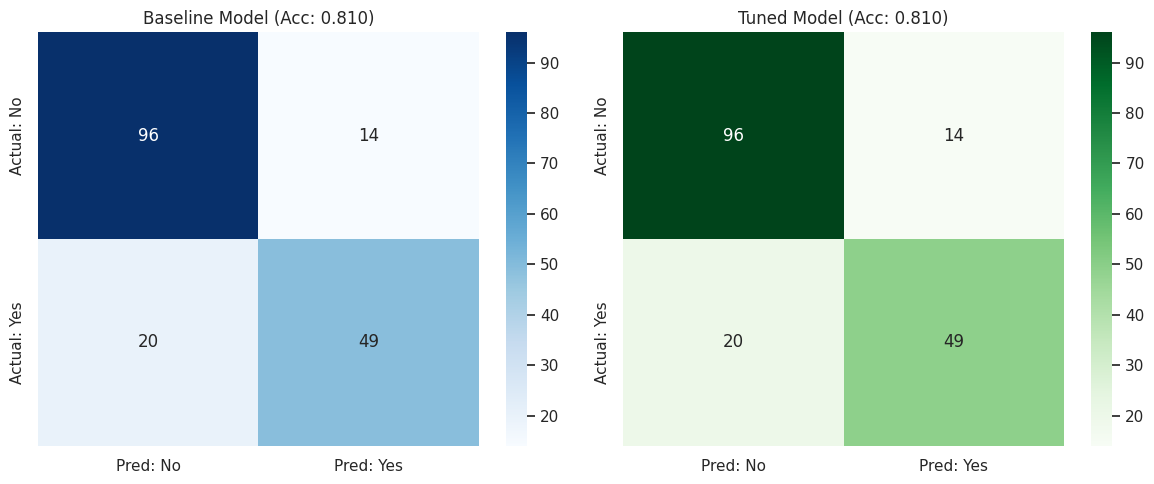

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_baseline = confusion_matrix(y_test, y_pred_baseline)
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: No', 'Pred: Yes'], yticklabels=['Actual: No', 'Actual: Yes'])
axes[0].set_title(f'Baseline Model (Acc: {baseline_accuracy:.3f})')

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Pred: No', 'Pred: Yes'], yticklabels=['Actual: No', 'Actual: Yes'])
axes[1].set_title(f'Tuned Model (Acc: {tuned_accuracy:.3f})')

plt.tight_layout()
plt.savefig('before_after_confusion_matrices.png', bbox_inches='tight')
plt.show()

## 11. Summary

- Loaded and re-prepared the Titanic dataset the same way as the earlier classification task.
- Confirmed the target is moderately imbalanced (~62% / ~38%).
- Computed precision, recall, and F1-score with `classification_report`, and showed concretely that a model which always predicts the majority class scores a deceptively high accuracy while having zero recall for the minority class.
- Tuned `C` and `penalty` with `GridSearchCV` (5-fold cross-validation, optimizing for F1-score).
- Compared baseline vs. tuned model performance in a before/after table and side-by-side confusion matrices.
